# 04 Resonator Power Chevron

Refine the readout operating point with a 2D resonator power spectroscopy scan after the resonator center frequency has been identified in notebook 03.

## 1. Shared Session Bootstrap

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    ResonatorPowerSpectroscopy,
    load_stage_checkpoint,
    open_notebook_stage,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="04_resonator_power_chevron",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)

resonator_stage_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="03_resonator_spectroscopy",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")
if resonator_stage_checkpoint is not None:
    print(
        "Prior stage 03 status: "
        f"{resonator_stage_checkpoint['status']}"
        f" ({resonator_stage_checkpoint['summary']})"
    )
    fitted_stage_f0_hz = resonator_stage_checkpoint.get("advisory_outputs", {}).get("fitted_f0_hz")
    if fitted_stage_f0_hz is not None:
        print(f"Stage 03 fitted center: {float(fitted_stage_f0_hz) / 1e9:.6f} GHz")

2026-03-22 00:51:21,536 - qm - INFO     - Starting session: 7a6caf08-d7ef-459e-a734-4110fca43e81
[INFO] 2026-03-22 00:51:27,586 qubox.legacy.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:51:27,587 qubox.legacy.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:51:27,587 qubox.legacy.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
[INFO] 2026-03-22 00:51:27,588 qubox.legacy.hardware.config_engine: Hardware loaded from E:\qubox\samples\post_cavity_sample_A\config\hardware.json


c:\Users\jl82323\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-22 00:51:31,390 - qm - INFO     - Performing health check
2026-03-22 00:51:31,394 - qm - INFO     - Health check passed
[INFO] 2026-03-22 00:51:31,396 qubox.legacy.pulses.manager: Loaded pulse files from: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
[INFO] 2026-03-22 00:51:31,396 qubox.legacy.calibration.store: Loading calibration from E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:51:31,399 qubox.legacy.devices.device_manager: Loaded 4 device spec(s) from E:\qubox\samples\post_cavity_sample_A\config\devices.json
[INFO] 2026-03-22 00:51:31,400 qubox.legacy.devices.device_manager: Connecting device 'octave_external_lo2' ...
[ERROR] 2026-03-22 00:51:31,401 qubox.legacy.devices.device_manager: FAILED to connect 'octave_external_lo2' after 0.00s: octave_external_lo2: instrumentserver backend not found.
Traceback (most recent call last):
  File "E:\qubox\qubox\legacy\devices\device_manage

## 2. Chevron Defaults

These reduced-cost defaults are intentionally a little wider than the runtime `attr.ro_fq` so the chevron still captures the resonator shift typically seen in notebook 03 without forcing a manual edit on every bring-up pass.

In [4]:
RESONATOR_POWER_READOUT_OP = "readout"
RESONATOR_POWER_CENTER_HZ = float(getattr(attr, "ro_fq", 0.0))
RESONATOR_POWER_SPAN_HZ = 12 * u.MHz
RESONATOR_POWER_RF_BEGIN = int(RESONATOR_POWER_CENTER_HZ - RESONATOR_POWER_SPAN_HZ / 2)
RESONATOR_POWER_RF_END = int(RESONATOR_POWER_CENTER_HZ + RESONATOR_POWER_SPAN_HZ / 2)
RESONATOR_POWER_DF = 400 * u.kHz
RESONATOR_POWER_G_MIN = 0.2
RESONATOR_POWER_G_MAX = 1.0
RESONATOR_POWER_N_A = 17
RESONATOR_POWER_N_AVG = 150
RESONATOR_POWER_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)

print("Resonator power chevron verification settings:")
print(f"  center: {RESONATOR_POWER_CENTER_HZ / 1e9:.6f} GHz")
print(f"  rf window: {RESONATOR_POWER_RF_BEGIN / 1e9:.6f} -> {RESONATOR_POWER_RF_END / 1e9:.6f} GHz")
print(f"  df: {RESONATOR_POWER_DF / 1e3:.1f} kHz")
print(f"  gain range: {RESONATOR_POWER_G_MIN:.3f} -> {RESONATOR_POWER_G_MAX:.3f}")
print(f"  gain samples: {RESONATOR_POWER_N_A}")
print(f"  n_avg: {RESONATOR_POWER_N_AVG}")
print(f"  ro_therm_clks: {RESONATOR_POWER_RO_THERM_CLKS}")

Resonator power chevron verification settings:
  center: 8.596223 GHz
  rf window: 8.590223 -> 8.602223 GHz
  df: 400.0 kHz
  gain range: 0.200 -> 1.000
  gain samples: 17
  n_avg: 150
  ro_therm_clks: 1000


## 3. Run the 2D Chevron

[INFO] 2026-03-22 00:52:00,009 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:00,011 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:00,012 qubox.legacy.experiments.experiment_base: Resolved ro_therm_clks=1000 (source=override)
[INFO] 2026-03-22 00:52:00,187 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:00,187 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:00,188 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.15

Running Program...:  99%|█████████▉| 149/150 [00:00<00:00, 332.73it/s]

[INFO] 2026-03-22 00:52:00,912 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405505
No errors
[INFO] 2026-03-22 00:52:00,938 qubox.legacy.hardware.program_runner: Job halted successfully.


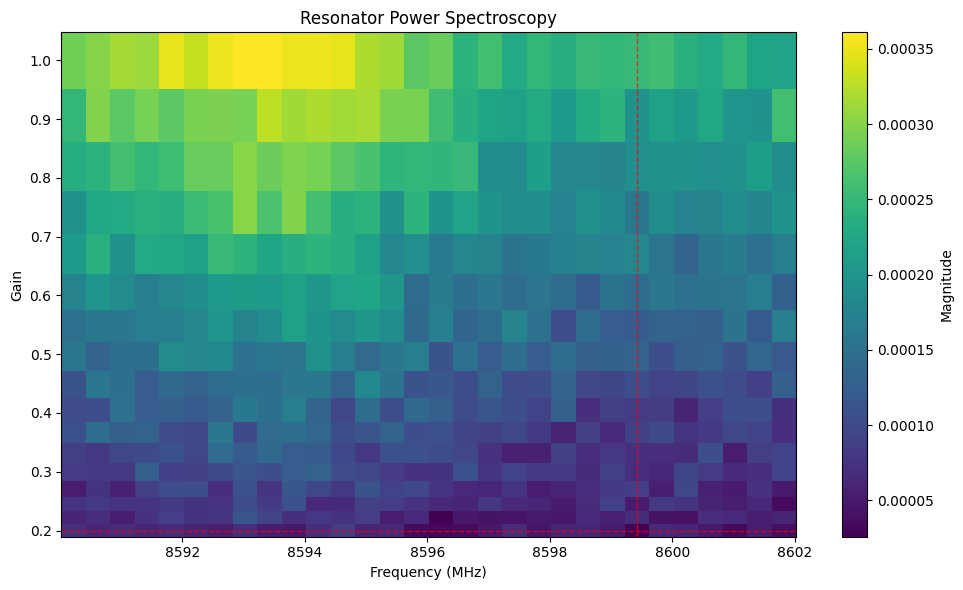

Optimal frequency: 8.599423 GHz
Optimal gain: 0.200000
Runtime attr.ro_fq delta: +3.200 MHz
Legacy reference delta: +3.200 MHz


In [ ]:
power_chevron = ResonatorPowerSpectroscopy(session)
power_chevron_result = power_chevron.run(
    RESONATOR_POWER_READOUT_OP,
    rf_begin=RESONATOR_POWER_RF_BEGIN,
    rf_end=RESONATOR_POWER_RF_END,
    df=RESONATOR_POWER_DF,
    g_min=RESONATOR_POWER_G_MIN,
    g_max=RESONATOR_POWER_G_MAX,
    N_a=RESONATOR_POWER_N_A,
    n_avg=RESONATOR_POWER_N_AVG,
    ro_therm_clks=RESONATOR_POWER_RO_THERM_CLKS,
)
power_chevron_analysis = power_chevron.analyze(power_chevron_result)
power_chevron.plot(power_chevron_analysis)

optimal_freq = float(power_chevron_analysis.metrics.get("optimal_freq", np.nan))
optimal_gain = float(power_chevron_analysis.metrics.get("optimal_gain", np.nan))

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="04_resonator_power_chevron",
    status="characterized",
    summary="Characterized the resonator operating point without applying calibration changes.",
    consumed_inputs={
        "readout_op": RESONATOR_POWER_READOUT_OP,
        "rf_begin_hz": RESONATOR_POWER_RF_BEGIN,
        "rf_end_hz": RESONATOR_POWER_RF_END,
        "df_hz": RESONATOR_POWER_DF,
        "gain_min": RESONATOR_POWER_G_MIN,
        "gain_max": RESONATOR_POWER_G_MAX,
        "gain_samples": RESONATOR_POWER_N_A,
        "n_avg": RESONATOR_POWER_N_AVG,
    },
    persisted_outputs={},
    advisory_outputs={
        "optimal_freq_hz": optimal_freq,
        "optimal_gain": optimal_gain,
    },
    next_stage="05_qubit_spectroscopy_pulse_calibration",
    notes=[
        "This stage is characterization-only in the numbered workflow.",
        "Notebook 05 may use the chosen readout operating point as advisory context, but it must not assume any readout calibration was committed here.",
    ],
    metrics=dict(power_chevron_analysis.metrics),
)

print(f"Optimal frequency: {optimal_freq / 1e9:.6f} GHz")
print(f"Optimal gain: {optimal_gain:.6f}")
print(f"Runtime attr.ro_fq delta: {(optimal_freq - float(attr.ro_fq)) / 1e6:+.3f} MHz")
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 4. Chevron Maps

Plot explicit `pcolormesh` maps for magnitude and phase, then overlay the chosen operating point against the current runtime readout frequency.

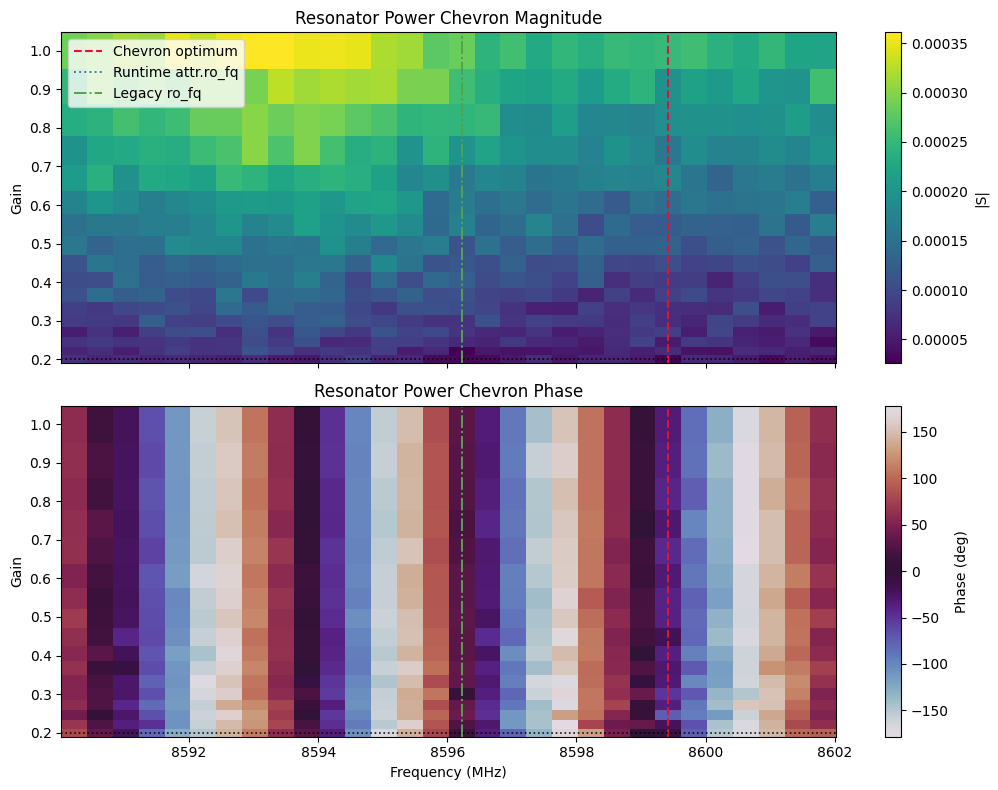

Optimal frequency: 8.599423 GHz
Optimal gain: 0.200000
Runtime delta: +3.200 MHz
Legacy delta: +3.200 MHz


In [ ]:
if "power_chevron_analysis" not in globals():
    print("Run the power-chevron cell above to generate the magnitude and phase chevron maps.")
else:
    frequencies_hz = np.asarray(power_chevron_analysis.data.get("frequencies", []), dtype=float)
    gains = np.asarray(power_chevron_analysis.data.get("gains", []), dtype=float)
    S = np.asarray(power_chevron_analysis.data.get("S", []))
    if frequencies_hz.size == 0 or gains.size == 0 or S.size == 0:
        raise RuntimeError("Resonator power chevron analysis did not expose frequencies/gains/S for plotting.")

    if S.shape == (frequencies_hz.size, gains.size):
        Z = S.T
    elif S.shape == (gains.size, frequencies_hz.size):
        Z = S
    else:
        raise RuntimeError(f"Unexpected resonator power spectroscopy shape: {S.shape}")

    def centers_to_edges(values: np.ndarray) -> np.ndarray:
        if values.size == 1:
            return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)
        mids = 0.5 * (values[1:] + values[:-1])
        first = values[0] - (mids[0] - values[0])
        last = values[-1] + (values[-1] - mids[-1])
        return np.concatenate(([first], mids, [last]))

    optimal_freq_hz = float(power_chevron_analysis.metrics.get("optimal_freq", np.nan))
    optimal_gain = float(power_chevron_analysis.metrics.get("optimal_gain", np.nan))
    freq_mhz = frequencies_hz / 1e6
    freq_edges_mhz = centers_to_edges(freq_mhz)
    gain_edges = centers_to_edges(gains)
    magnitude = np.abs(Z)
    phase_deg = np.angle(Z, deg=True)

    fig, axes = plt.subplots(2, 1, figsize=(10.5, 8), sharex=True)

    pcm_mag = axes[0].pcolormesh(freq_edges_mhz, gain_edges, magnitude, shading="auto")
    fig.colorbar(pcm_mag, ax=axes[0], label="|S|")
    axes[0].set_ylabel("Gain")
    axes[0].set_title("Resonator Power Chevron Magnitude")

    pcm_phase = axes[1].pcolormesh(freq_edges_mhz, gain_edges, phase_deg, shading="auto", cmap="twilight")
    fig.colorbar(pcm_phase, ax=axes[1], label="Phase (deg)")
    axes[1].set_xlabel("Frequency (MHz)")
    axes[1].set_ylabel("Gain")
    axes[1].set_title("Resonator Power Chevron Phase")

    for ax in axes:
        if np.isfinite(optimal_freq_hz):
            ax.axvline(optimal_freq_hz / 1e6, color="crimson", ls="--", lw=1.5, label="Chevron optimum")
        ax.axvline(float(attr.ro_fq) / 1e6, color="#4c78a8", ls=":", lw=1.4, label="Runtime attr.ro_fq")
        if np.isfinite(optimal_gain):
            ax.axhline(optimal_gain, color="black", ls=":", lw=1.2, alpha=0.9)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles[:2], labels[:2], loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Optimal frequency: {optimal_freq_hz / 1e9:.6f} GHz")
    print(f"Optimal gain: {optimal_gain:.6f}")
    print(f"Runtime delta: {(optimal_freq_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")